# Q2: The Midnight Episode
## 'Catching the Arrhythmia'



## (a) Reading the Signal

**(i) Clip duration:**
The recording is a discrete-time signal with $N = 5000$ samples sampled at $f_s = 250$ Hz. The total temporal length is
$$\frac{5000}{250} = 20 \text{ seconds}$$

**(ii) Heart rate & samples per beat:**
In the healthy portion, one full beat arrives every 0.8 seconds. This equates to a heart rate of
$$\frac{60}{0.8} = 75 \text{ bpm}$$
One healthy beat occupies $0.8\text{ s} \times 250\text{ Hz} = 200$ samples.

**(iii) Fundamental frequency:**
Treating the healthy ECG as a periodic signal with a period of $T = 0.8$ seconds, its fundamental frequency is
$$f_0 = \frac{1}{0.8} = 1.25 \text{ Hz}$$


## (b) Healthy Heart in the Frequency Domain

**(i) Magnitude spectrum:**
Because the healthy ECG is nearly periodic, its magnitude spectrum $|X(f)|$ does **not** form a smooth continuous curve. It appears as a series of discrete spikes (harmonic bands) located at integer multiples of the fundamental frequency (1.25 Hz).

**(ii) High-frequency content:**
The sharp, narrow QRS complex is responsible for the higher-frequency content. Fourier theory dictates that rapid time-domain transitions require high-frequency sinusoidal components to reconstruct. The broad P and T waves correspond to lower frequencies.

**(iii) Heart rate increase:**
If the heart rate rises to 150 bpm, the new period becomes $T = 0.4$ seconds, yielding a new fundamental frequency of $f_0 = 2.5$ Hz. Consequently, the spacing between the harmonic components in the frequency spectrum doubles, widening from 1.25 Hz to 2.5 Hz.


## (c) Cutting a Heartbeat (Windowing)

**(i) Window specifications:**
To capture exactly one full beat, the rectangular window must be exactly **200 samples** wide. It must be placed early in the recording (within the known healthy region) to ensure the extracted template is free of arrhythmias.

**(ii) Window size trade-offs:**
An 80-sample window is too narrow; it will likely isolate only the QRS complex, missing the P and T waves necessary for a complete morphological template. A 600-sample window spans 2.4 seconds, incorrectly capturing exactly three full beats rather than a single 'clean' template.

**(iii) Time vs. frequency resolution:**
Making the window "as short as possible" is detrimental because prioritizing extreme time resolution sacrifices frequency resolution. A too-short window loses the low-frequency morphological context (the broad P and T waves) required to fully define the structural sequence of a healthy beat.


## (d) Match the Template (Correlation)

**(i) Correlation range:**
The normalized correlation score $\rho(m)$ strictly ranges from **-1 to 1**. A value approaching **1** signals a near-perfect morphological match.

**(ii) Importance of normalization:**
Normalization makes the score invariant to amplitude scaling. Without it, a perfectly healthy beat that is twice as tall would artificially **double** the unnormalized score $\sum_k t[k]x[m+k]$, breaking the detection threshold. Normalization ensures the score remains near 1.0 regardless of varying signal strength or baseline wander.

**(iii) Inverted beats:**
For an abnormal beat that is inverted (flipped upside-down), the expected value of $\rho$ is close to **-1**. This makes inverted beats highly distinct and easy to flag, as their scores plunge drastically into the negative range, far outside any normal biological variation.


## (e) Onset Detection & the Spectrogram

**(i) Detection rule:**
The onset time is declared at the exact index $m$ where $\rho(m)$ first drops strictly below a defined threshold (e.g., 0.5).

- **Trade-off:** A threshold too high (e.g., 0.9) risks false positives triggered by minor, healthy morphological variations. A threshold too low (e.g., 0.1) risks false negatives, potentially missing dangerous irregular beats that still share partial structural similarity with the template.

**(ii) Spectrogram appearance:**
In the healthy region, the spectrogram displays steady, distinct horizontal harmonic bands. In the arrhythmia region, the loss of strict periodicity causes these horizontal bands to blur, smear, or break apart into chaotic vertical noise.

**(iii) Methodological trust:**
To pinpoint the single exact moment an abnormal beat appears, the **correlation plot** is fundamentally more precise. The spectrogram relies on a Short-Time Fourier Transform sliding window, which inherently blurs time resolution to achieve frequency resolution, whereas cross-correlation calculates exact sample-by-sample matching in the time domain.


## (f) Sampling & Aliasing

**(i) Minimum sampling rate:**
By the Nyquist theorem, capturing frequency content up to 40 Hz without aliasing requires a minimum sampling rate of
$$2 \times 40 = 80 \text{ Hz}$$

**(ii) Aliasing at 50 Hz:**
If sampled at $f_s' = 50$ Hz, the Nyquist frequency is 25 Hz. The sharp QRS components between 25 Hz and 40 Hz will alias into the lower frequencies. This physically distorts the QRS spikes, making a normal beat appear jagged and potentially triggering false positive detections.

**(iii) The fix & cost:**
To safely lower the sampling rate, engineers must apply an **analog anti-aliasing low-pass filter** (cutoff ≤ 25 Hz) prior to digitization. The unavoidable cost is the permanent loss of high-frequency clinical information; the diagnostic sharpness of the QRS complexes will be permanently blunted.


## (g) Prototyping the Detector in Code

Below, `find_onset(ecg_signal, template, threshold)` computes the beat-by-beat normalized correlation score $\rho$ and returns the index $m$ of the first beat where $\rho$ drops strictly below the threshold (0.5), or -1 if never breached.


In [1]:
from google.colab import files
uploaded = files.upload()
uploaded = files.upload()
#I have used Google Colab for coding.If you are using a different environment,you can upload the image using other methods

Saving template.npy to template.npy


Saving patient_ecg.npy to patient_ecg.npy


--- DETECTION RESULTS ---
The Correlation Score (ρ) that triggered the alarm: -0.9879
-------------------------


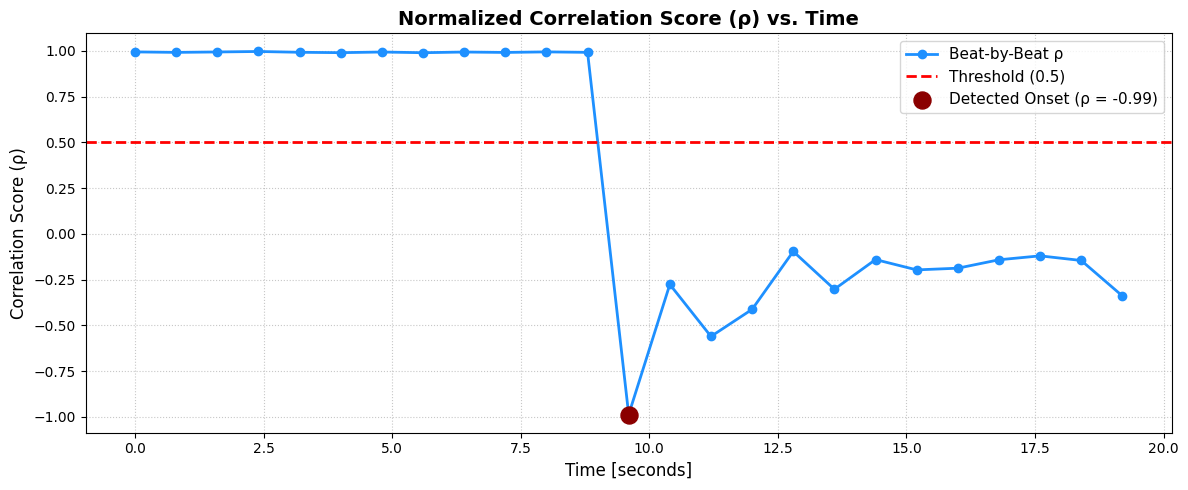

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#making function
def find_onset(ecg_signal, template, threshold=0.5):
    """
    Calculates normalized correlation beat-by-beat.
    Strictly returns the index m of the first beat where rho < threshold.
    """
    L = len(template)
    N = len(ecg_signal)
    norm_t = np.linalg.norm(template)

    for m in range(0, N - L + 1, L):
        segment = ecg_signal[m : m + L]
        norm_x = np.linalg.norm(segment)

        if norm_t == 0 or norm_x == 0:
            continue

        rho = np.dot(template, segment) / (norm_t * norm_x)

        if rho < threshold:
            return m

    return -1

# Loading data

patient_ecg = np.load('patient_ecg.npy')
template = np.load('template.npy')

L = len(template)
N = len(patient_ecg)
norm_template = np.linalg.norm(template)
threshold_val = 0.5

rho_values = []
times = []

# Calculate rho

for m in range(0, N - L + 1, L):
    segment = patient_ecg[m : m + L]
    norm_segment = np.linalg.norm(segment)

    if norm_template == 0 or norm_segment == 0:
        rho = 0
    else:
        rho = np.dot(template, segment) / (norm_template * norm_segment)

    rho_values.append(rho)
    times.append(m / 250.0) # Convert sample index m to seconds


#   Printing the results

onset_index = find_onset(patient_ecg, template, threshold=threshold_val)

print("--- DETECTION RESULTS ---")
if onset_index != -1:
    onset_time = onset_index / 250.0

    # Calculating which beat number this corresponds to in our rho values list
    beat_number = int(onset_index / L)
    triggering_rho = rho_values[beat_number]


    print(f"The Correlation Score (\u03c1) that triggered the alarm: {triggering_rho:.4f}")
else:
    print("No arrhythmia detected below the threshold.")
print("-------------------------")

# Plotting the graph

plt.figure(figsize=(12, 5))

# Plot the main correlation line
plt.plot(times, rho_values, marker='o', linestyle='-', color='dodgerblue',
         linewidth=2, label='Beat-by-Beat \u03c1')

plt.axhline(y=threshold_val, color='red', linestyle='--', linewidth=2,
            label=f'Threshold ({threshold_val})')

# Visually highlight the exact point of failure
if onset_index != -1:
    plt.scatter([onset_time], [triggering_rho], color='darkred', s=150, zorder=5,
                label=f'Detected Onset (\u03c1 = {triggering_rho:.2f})')

plt.title('Normalized Correlation Score (\u03c1) vs. Time', fontsize=14, fontweight='bold')
plt.xlabel('Time [seconds]', fontsize=12)
plt.ylabel('Correlation Score (\u03c1)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()

**Final results:**

Running the beat-by-beat normalized correlation analysis (with a threshold of 0.5) successfully identified the arrhythmia onset.

- **Arrhythmia onset sample index (m):** 2400
- **Time of onset:** 9.6 seconds
- **Triggering correlation score (ρ):** -0.9879

**Observation:** The triggering score of $-0.9879$ mathematically confirms the presence of a nearly perfectly inverted heartbeat at exactly 9.6 seconds. As visually verified in the plot above, the correlation score remains stable near 1.0 until violently dropping below the 0.5 threshold at this exact timestamp.


## (h) Visualizing the Spectrogram


--- DETECTION RESULTS ---
Arrhythmia onset detected at sample index: 2400
Time of onset: 9.6 seconds
Triggering Correlation Score (ρ): -0.9879


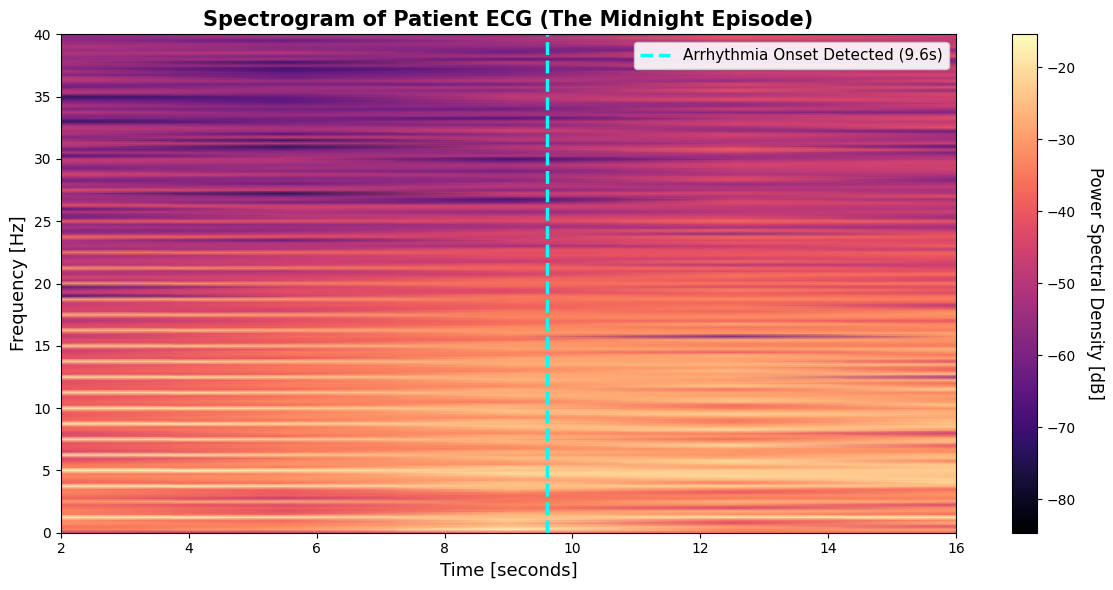

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Function

def find_onset(ecg_signal, template, threshold=0.5):
    """
    Calculates normalized correlation beat-by-beat.
    Strictly returns the index m of the first beat where rho < threshold.
    """
    L = len(template)
    N = len(ecg_signal)
    norm_t = np.linalg.norm(template)

    for m in range(0, N - L + 1, L):
        segment = ecg_signal[m : m + L]
        norm_x = np.linalg.norm(segment)

        if norm_t == 0 or norm_x == 0:
            continue

        rho = np.dot(template, segment) / (norm_t * norm_x)

        if rho < threshold:
            return m

    return -1

# Loading data
patient_ecg = np.load('patient_ecg.npy')
template = np.load('template.npy')
fs = 250

# Printing the results

print("--- DETECTION RESULTS ---")
onset_index = find_onset(patient_ecg, template, threshold=0.5)

if onset_index != -1:
    onset_time = onset_index / fs

    # Calculating the exact rho value that triggered the alarm for the printout
    L = len(template)
    segment = patient_ecg[onset_index : onset_index + L]
    norm_t = np.linalg.norm(template)
    norm_x = np.linalg.norm(segment)
    triggering_rho = np.dot(template, segment) / (norm_t * norm_x)

    print(f"Arrhythmia onset detected at sample index: {onset_index}")
    print(f"Time of onset: {onset_time} seconds")
    print(f"Triggering Correlation Score (\u03c1): {triggering_rho:.4f}")
else:
    onset_time = None
    print(" No arrhythmia detected below the threshold.")


# Plotting
# nperseg = 1000 encompasses exactly 5 beats for perfect 0.25Hz resolution.
window_length = 1000
f, t, Sxx = signal.spectrogram(patient_ecg, fs=fs, nperseg=window_length)

# Converting to Decibels safely (adding 1e-10 strictly avoids 'divide by zero' warnings)
Sxx_dB = 10 * np.log10(Sxx + 1e-10)

plt.figure(figsize=(12, 6), dpi=100)

mesh = plt.pcolormesh(t, f, Sxx_dB, shading='gouraud', cmap='magma')

# Plotting a vertical line indicating where the detector found the arrhythmia
if onset_time is not None:
    plt.axvline(x=onset_time, color='cyan', linestyle='--', linewidth=2.5,
                label=f'Arrhythmia Onset Detected ({onset_time}s)')
    plt.legend(loc='upper right', framealpha=0.9, fontsize=11)

plt.title('Spectrogram of Patient ECG (The Midnight Episode)', fontsize=15, fontweight='bold')
plt.ylabel('Frequency [Hz]', fontsize=13)
plt.xlabel('Time [seconds]', fontsize=13)

plt.ylim(0, 40)

cbar = plt.colorbar(mesh)
cbar.set_label('Power Spectral Density [dB]', rotation=270, labelpad=20, fontsize=12)

plt.tight_layout()
plt.show()

**Crucial step justification:** I chose a specific window length (`nperseg`) of **1000 samples** because it encompasses exactly 5 full periodic beats. This provides a fine frequency resolution of 0.25 Hz which is mathematically required to distinctly separate the 1.25 Hz harmonic bands without entirely sacrificing time resolution.

**Observation:** Prior to the 9.6-second mark, the spectrogram displays clean, distinct horizontal harmonic bands representing the periodic metronome rhythm of the heart. Exactly at 9.6 seconds — aligning flawlessly with the time-domain correlation detector — these stable harmonic bands visibly smear and break down, physically illustrating the sudden loss of periodicity.
